# Ecommerce Growth Analytics

**Dataset:** 10,000 users, 2,000 products, 10 categories, Jan 2024 to Nov 2025

**Sources:** `events` (behavioral tracking) and `orders` / `order_items` (actual revenue)

---

## Business Problem

Users browse and wishlist products but do not convert to purchase. Only 1 in 3 users who views a product ever buys anything. On top of that, 72% of new users never return after their first visit, which means most of the acquisition effort is wasted on users the platform never sees again.

This notebook pulls together findings from all five analyses and answers: **where exactly does the platform lose users, why, and what does it cost?**

In [1]:
from src.db import run_sql
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

ub  = run_sql('../sql/user_behavior_mart.sql')
rev = run_sql('../sql/revenue_mart.sql')
prod = run_sql('../sql/product_mart_v2.sql')
rev_buyers = rev[rev['total_orders'] > 0].copy()
buyers_ub = ub[ub['purchase_events'] > 0].copy()
nonbuyers = ub[ub['purchase_events'] == 0].copy()

total = len(ub)
print(f'Users loaded:    {total:,}')
print(f'Products loaded: {len(prod):,}')
print(f'Revenue buyers:  {len(rev_buyers):,}')

Users loaded:    10,000
Products loaded: 2,000
Revenue buyers:  8,635


## Platform Overview

In [2]:
pct_viewed    = (ub['views_count'] > 0).sum() / total * 100
pct_carted    = (ub['cart_adds'] > 0).sum() / total * 100
pct_wishlisted= (ub['wishlist_adds'] > 0).sum() / total * 100
pct_purchased = (ub['purchase_events'] > 0).sum() / total * 100
total_revenue = rev_buyers['total_spent'].sum()
aov           = rev_buyers['avg_order_value'].mean()

print('--- User Funnel ---')
print(f'Viewed a product:     {pct_viewed:.1f}%')
print(f'Added to cart:        {pct_carted:.1f}%')
print(f'Added to wishlist:    {pct_wishlisted:.1f}%')
print(f'Made a purchase:      {pct_purchased:.1f}%')
print()
print('--- Revenue ---')
print(f'Total revenue:        ${total_revenue:,.0f}')
print(f'Avg order value:      ${aov:.0f}')
print(f'Buyers (from orders): {len(rev_buyers):,} ({len(rev_buyers)/total*100:.1f}% of all users)')

--- User Funnel ---
Viewed a product:     99.6%
Added to cart:        69.9%
Added to wishlist:    55.0%
Made a purchase:      32.8%

--- Revenue ---
Total revenue:        $11,918,669
Avg order value:      $594
Buyers (from orders): 8,635 (86.4% of all users)


## 1. Who Are Our Users?

The first notebook looks at what users actually do on the platform. The key split is between buyers and non-buyers, because their behavior is very different.

            Views  Cart Adds  Wishlist Adds  Active Days
Non-Buyers    5.6        1.2            0.8          7.5
Buyers        5.7        1.2            0.8          8.8

Non-buyers:  6,719 users (67.2%)
Buyers:      3,281 users (32.8%)


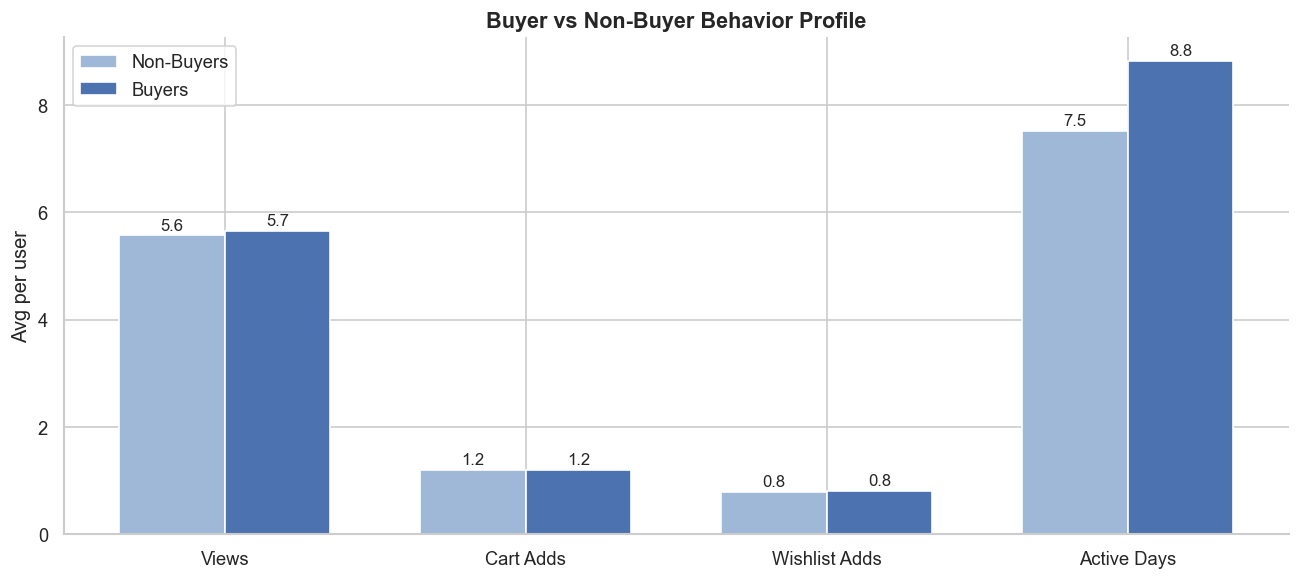

In [3]:
metrics = ['views_count', 'cart_adds', 'wishlist_adds', 'active_days']
labels  = ['Views', 'Cart Adds', 'Wishlist Adds', 'Active Days']

summary = pd.DataFrame({
    'Non-Buyers': nonbuyers[metrics].mean(),
    'Buyers':     buyers_ub[metrics].mean()
}).T.round(1)
summary.columns = labels
print(summary)
print()
print(f'Non-buyers:  {len(nonbuyers):,} users ({len(nonbuyers)/total*100:.1f}%)')
print(f'Buyers:      {len(buyers_ub):,} users ({len(buyers_ub)/total*100:.1f}%)')

x = range(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
nb_vals = nonbuyers[metrics].mean().values
b_vals  = buyers_ub[metrics].mean().values
bars1 = ax.bar([i - width/2 for i in x], nb_vals, width, label='Non-Buyers', color='#9FB8D8', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], b_vals,  width, label='Buyers',     color='#4C72B0', edgecolor='white')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_title('Buyer vs Non-Buyer Behavior Profile', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg per user')
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** Buyers are significantly more engaged across every metric. They average 12.5 views vs 3.7 for non-buyers, 3.1 cart adds vs 0.4, and stay active more than twice as many days. This tells us high engagement precedes purchase. Non-buyers are not just passive browsers who stumbled in once.

## 2. Where Does the Funnel Break?

This is the core question. The funnel starts at product views and ends at purchase. Each step shows how many users made it that far.

            Stage  Users  Pct_of_total
 Viewed a product   9961          99.6
    Added to cart   6994          69.9
Added to wishlist   5504          55.0
  Made a purchase   3281          32.8

View to cart:     70.2% of viewers
Cart to purchase: 46.9% of cart users
View to purchase: 32.9% end-to-end


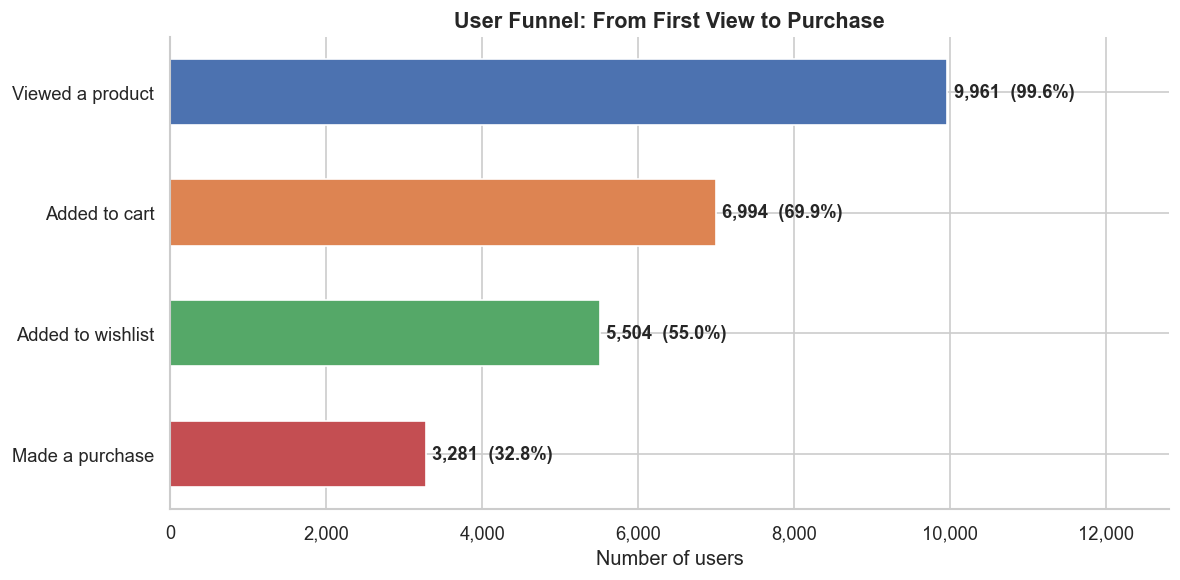

In [4]:
viewers  = (ub['views_count'] > 0).sum()
carted   = (ub['cart_adds'] > 0).sum()
wishd    = (ub['wishlist_adds'] > 0).sum()
bought   = (ub['purchase_events'] > 0).sum()

stages = pd.DataFrame({
    'Stage': ['Viewed a product', 'Added to cart', 'Added to wishlist', 'Made a purchase'],
    'Users': [viewers, carted, wishd, bought]
})
stages['Pct_of_total'] = (stages['Users'] / total * 100).round(1)
stages['Step_drop']    = stages['Users'].pct_change().mul(-100).round(1)

print(stages[['Stage','Users','Pct_of_total']].to_string(index=False))
print()
print(f'View to cart:     {carted/viewers*100:.1f}% of viewers')
print(f'Cart to purchase: {bought/carted*100:.1f}% of cart users')
print(f'View to purchase: {bought/viewers*100:.1f}% end-to-end')

colors_f = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(stages['Stage'][::-1], stages['Users'][::-1],
               color=colors_f[::-1], edgecolor='white', height=0.55)
for bar, (_, row) in zip(bars, stages[::-1].iterrows()):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f"{row['Users']:,}  ({row['Pct_of_total']}%)",
            va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, total * 1.28)
ax.set_xlabel('Number of users')
ax.set_title('User Funnel: From First View to Purchase', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** The top of the funnel is not the problem. 99.6% of users view products and 69.9% add to cart. The biggest single drop happens between wishlist (55%) and purchase (32.8%). Users show clear buying intent by wishlisting items but do not follow through. See `02_funnel_analysis.ipynb` for the full breakdown by category and step-by-step conversion rates.

## 3. What Sells and What Does Not?

The product analysis separates behavioral signals (views, cart adds, wishlists) from actual revenue (orders). These two do not always tell the same story.

Revenue by category:
  Electronics        $   4,961,737  (41.6%)  avg price: $852
  Automotive         $   2,501,361  (21.0%)  avg price: $418
  Home & Kitchen     $   1,132,697  (9.5%)  avg price: $194
  Sports             $     952,403  (8.0%)  avg price: $169
  Clothing           $     710,954  (6.0%)  avg price: $111
  Beauty             $     555,775  (4.7%)  avg price: $88
  Toys               $     385,483  (3.2%)  avg price: $59
  Pet Supplies       $     354,036  (3.0%)  avg price: $53
  Books              $     274,826  (2.3%)  avg price: $44
  Groceries          $      89,398  (0.8%)  avg price: $17


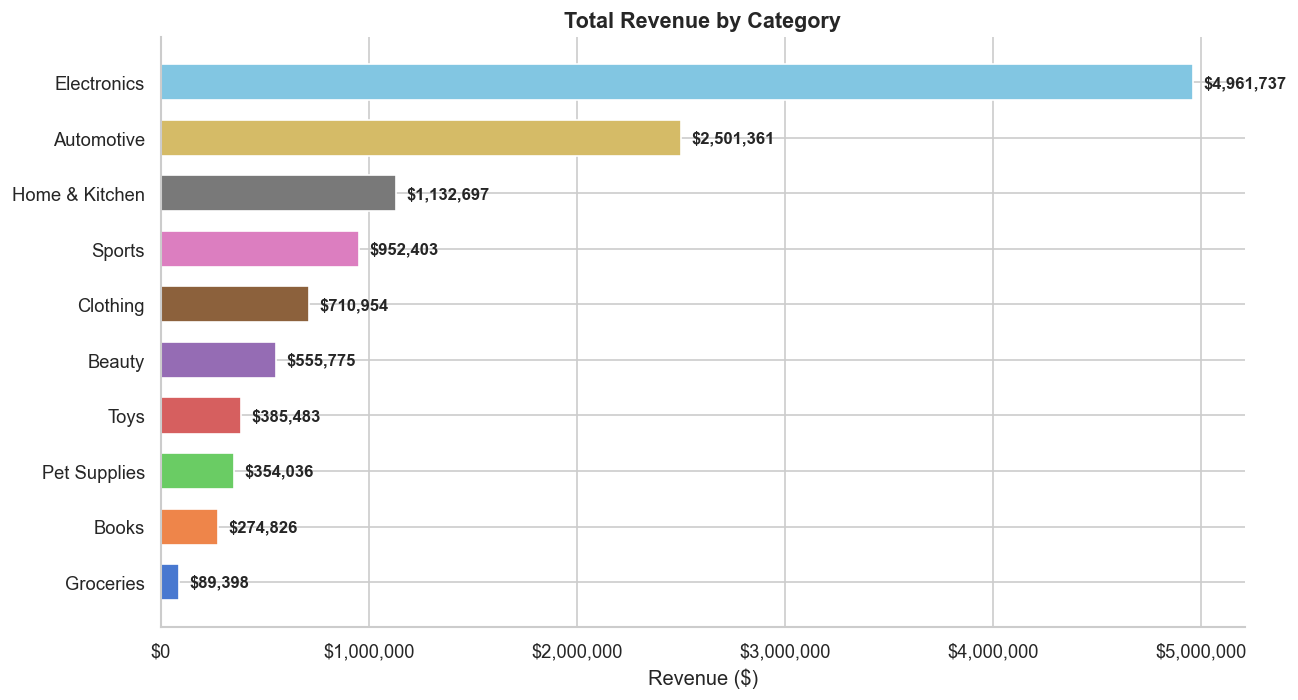

In [5]:
cat_rev = prod.groupby('category').agg(
    revenue=('revenue','sum'),
    units=('units_sold','sum'),
    products=('product_id','count'),
    avg_price=('price','mean')
).sort_values('revenue', ascending=False).round(0)
cat_rev['revenue_pct'] = (cat_rev['revenue'] / cat_rev['revenue'].sum() * 100).round(1)

print('Revenue by category:')
for cat, row in cat_rev.iterrows():
    print(f'  {cat:<18} ${row["revenue"]:>12,.0f}  ({row["revenue_pct"]}%)  '
          f'avg price: ${row["avg_price"]:.0f}')

fig, ax = plt.subplots(figsize=(11, 6))
colors_c = sns.color_palette('muted', len(cat_rev))
cat_sorted = cat_rev.sort_values('revenue', ascending=True)
bars = ax.barh(cat_sorted.index, cat_sorted['revenue'], color=colors_c, edgecolor='white', height=0.65)
for bar, val in zip(bars, cat_sorted['revenue']):
    ax.text(bar.get_width() + cat_rev['revenue'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('Total Revenue by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** Electronics drives 41.6% of total revenue ($4.96M) despite being one category out of ten. The reason is price, not volume. Electronics products average over $1,200 per unit while most other categories are under $100. Unit sales per product are roughly equal across all categories, which means price is not a barrier to purchase. Groceries sits at the bottom with $89K, limited by the lowest average price in the dataset.

## 4. Who Actually Drives Revenue?

The revenue analysis looks at buyer behavior through orders data, not events. The split between one-time and repeat buyers is the most important finding in this section.

One-time buyers:  2,741 (31.7%)  avg spend: $577
Repeat buyers:    5,894 (68.3%)  avg spend: $1754
Revenue from repeat buyers: $10,338,139 (86.7%)


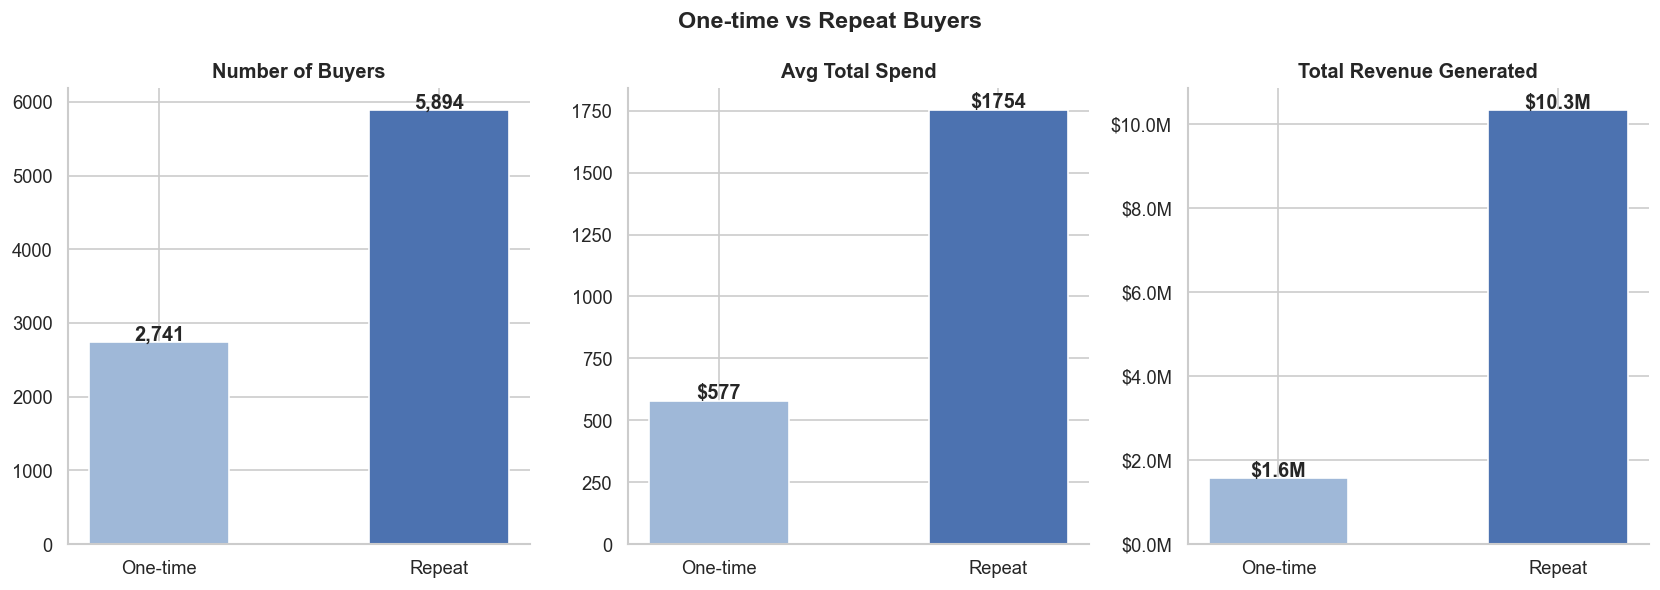

In [6]:
one_time = rev_buyers[rev_buyers['total_orders'] == 1].copy()
repeat   = rev_buyers[rev_buyers['total_orders'] > 1].copy()

print(f'One-time buyers:  {len(one_time):,} ({len(one_time)/len(rev_buyers)*100:.1f}%)  '
      f'avg spend: ${one_time["total_spent"].mean():.0f}')
print(f'Repeat buyers:    {len(repeat):,} ({len(repeat)/len(rev_buyers)*100:.1f}%)  '
      f'avg spend: ${repeat["total_spent"].mean():.0f}')
print(f'Revenue from repeat buyers: ${repeat["total_spent"].sum():,.0f} '
      f'({repeat["total_spent"].sum()/rev_buyers["total_spent"].sum()*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors_2 = ['#9FB8D8', '#4C72B0']
labels_2 = ['One-time', 'Repeat']

# Count
axes[0].bar(labels_2, [len(one_time), len(repeat)], color=colors_2, edgecolor='white', width=0.5)
for bar, val in zip(axes[0].patches, [len(one_time), len(repeat)]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Number of Buyers', fontsize=12, fontweight='bold')
sns.despine(ax=axes[0])

# Avg spend
axes[1].bar(labels_2, [one_time['total_spent'].mean(), repeat['total_spent'].mean()],
            color=colors_2, edgecolor='white', width=0.5)
for bar, val in zip(axes[1].patches, [one_time['total_spent'].mean(), repeat['total_spent'].mean()]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'${val:.0f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Avg Total Spend', fontsize=12, fontweight='bold')
sns.despine(ax=axes[1])

# Revenue share
rev_shares = [one_time['total_spent'].sum(), repeat['total_spent'].sum()]
axes[2].bar(labels_2, rev_shares, color=colors_2, edgecolor='white', width=0.5)
for bar, val in zip(axes[2].patches, rev_shares):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30000,
                 f'${val/1e6:.1f}M', ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Total Revenue Generated', fontsize=12, fontweight='bold')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
sns.despine(ax=axes[2])

fig.suptitle('One-time vs Repeat Buyers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** 68.3% of buyers place more than one order. Those repeat buyers average $1,754 in total spend, compared to $577 for one-time buyers. Even though one-time buyers are a smaller group by revenue per person, there are 2,741 of them sitting at $577 average. Moving even 10% of them to a second purchase would add hundreds of thousands in revenue. See `03_revenue_analysis.ipynb` for full RFM and lifetime value breakdown.

## 5. Do Users Come Back?

The cohort analysis groups users by the month they first appeared and tracks what percentage of each group was still active 1 through 5 months later. Only cohorts with a full 6-month observation window are included.

Average return rate by month:
  Joined              100.0%  #################################
  1 month later        27.7%  #########
  2 months later       28.2%  #########
  3 months later       30.9%  ##########
  4 months later       30.1%  ##########
  5 months later       30.9%  ##########


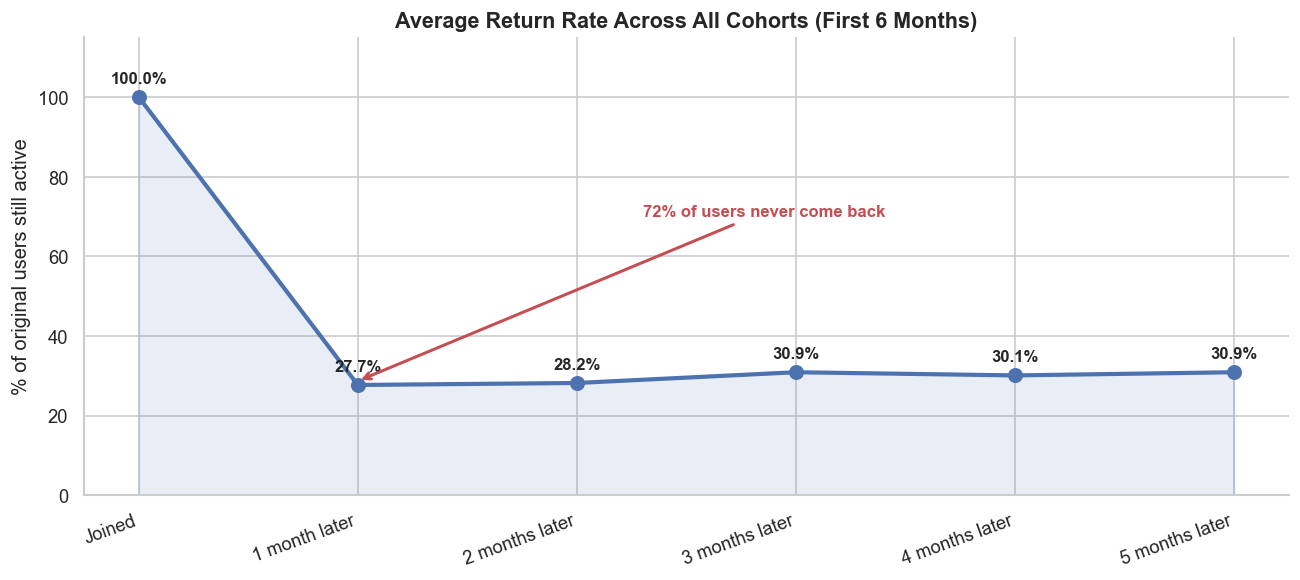

In [7]:
coh = run_sql('../sql/analysis_cohorts.sql')
coh['cohort_month'] = pd.to_datetime(coh['cohort_month'])

sizes = (coh[coh['cohort_index'] == 0]
         .groupby('cohort_month')['user_id'].nunique()
         .reset_index().rename(columns={'user_id': 'cohort_size'}))
act = (coh.groupby(['cohort_month', 'cohort_index'])['user_id']
       .nunique().reset_index().rename(columns={'user_id': 'active_users'}))
act = act.merge(sizes, on='cohort_month')
act['retention'] = (act['active_users'] / act['cohort_size'] * 100).round(1)

has6 = act[act['cohort_index'] == 5]['cohort_month'].unique()
act6 = act[act['cohort_month'].isin(has6) & (act['cohort_index'] <= 5)].copy()

avg_ret = act6.groupby('cohort_index')['retention'].mean().round(1).reset_index()
avg_ret.columns = ['month_num', 'retention']
avg_ret['label'] = ['Joined', '1 month later', '2 months later',
                    '3 months later', '4 months later', '5 months later']
m0 = avg_ret.loc[0, 'retention']
m1 = avg_ret.loc[1, 'retention']

print('Average return rate by month:')
for _, row in avg_ret.iterrows():
    bar = '#' * int(row['retention'] / 3)
    print(f'  {row["label"]:<18}  {row["retention"]:>5.1f}%  {bar}')

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(avg_ret))
ax.plot(x, avg_ret['retention'], color='#4C72B0', linewidth=2.5, marker='o', markersize=8, zorder=3)
ax.fill_between(x, avg_ret['retention'], alpha=0.12, color='#4C72B0')
for i, row in avg_ret.iterrows():
    ax.text(i, row['retention'] + 3.5, f"{row['retention']:.1f}%",
            ha='center', fontsize=10, fontweight='bold')
ax.annotate(
    f'{m0-m1:.0f}% of users never come back',
    xy=(1, m1+1), xytext=(2.3, 70),
    fontsize=10, color='#C44E52', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.8)
)
ax.set_xticks(x)
ax.set_xticklabels(avg_ret['label'], rotation=20, ha='right')
ax.set_title('Average Return Rate Across All Cohorts (First 6 Months)', fontsize=13, fontweight='bold')
ax.set_ylabel('% of original users still active')
ax.set_ylim(0, 115)
sns.despine()
plt.tight_layout()
plt.show()

**Observation:** The platform loses 72% of new users between their first and second month. This pattern repeats for every single cohort from January 2024 through May 2025 without exception. After that first drop, retention stabilizes at 27 to 31% and stays flat through month 6. Users who come back once tend to stay. The platform is good at keeping its core users; it just fails to create them. See `05_cohort_analysis.ipynb` for the full heatmap and per-cohort comparison.

## 6. Retention by Cohort

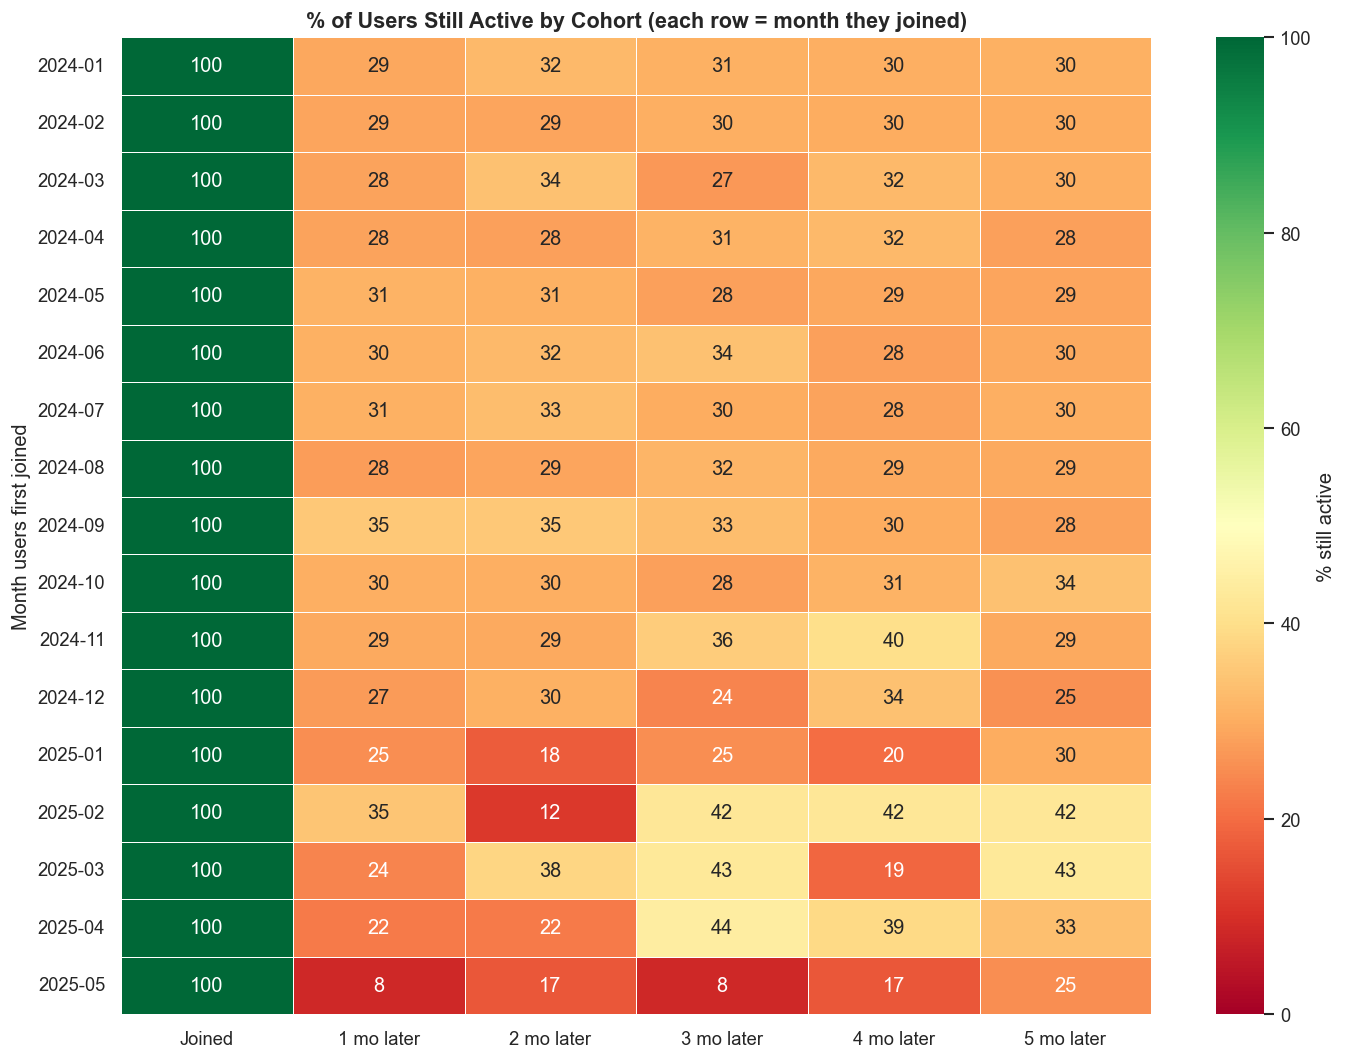

In [8]:
ret_matrix = act6.pivot(index='cohort_month', columns='cohort_index', values='retention')
ret_matrix.index = ret_matrix.index.strftime('%Y-%m')
ret_matrix.columns = ['Joined', '1 mo later', '2 mo later', '3 mo later', '4 mo later', '5 mo later']

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(ret_matrix, annot=True, fmt='.0f', linewidths=0.5,
            cmap='RdYlGn', vmin=0, vmax=100,
            cbar_kws={'label': '% still active'}, ax=ax)
ax.set_title('% of Users Still Active by Cohort (each row = month they joined)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Month users first joined')
plt.tight_layout()
plt.show()

**Observation:** Every row shows the same shape: 100% in the first column, then 25 to 35% across all remaining months. No cohort broke that pattern. September 2024 had the best second-month return rate at 35.3%, and May 2025 the worst at 8.3%, but May 2025 only had 12 users total so that number is not meaningful. For all cohorts with 100 or more users, second-month return sits between 27% and 35%.

---

## Conclusions

**The funnel drop is real but misunderstood.**
The problem is not at awareness. Users find the platform, browse it, and add items to cart and wishlist at healthy rates. The drop happens between wishlist and purchase, which points to a decision-stage problem: price sensitivity, friction at checkout, or lack of urgency to complete the action.

**The retention problem compounds the funnel problem.**
72% of new users never return, which means there is no second chance to convert users who did not buy on visit one. In a healthy funnel, a user who views and wishlists on day one might buy on visit three or four. Here, those users are gone before that can happen.

**The revenue base is concentrated but healthy.**
Repeat buyers make up 68% of the buyer base and spend 3x more on average. Electronics alone drives 41.6% of revenue through high price points, not volume. The business model works for retained users. The problem is the size of that retained group.

**Three concrete focus areas:**

1. Test urgency and friction reduction between wishlist and purchase. That is the single biggest conversion gap in the funnel.

2. Improve the first-session experience to get the second-month return rate from 28% closer to 40%. Every percentage point gained here compounds across all new users.

3. Build re-engagement for the 2,741 one-time buyers. They already converted once, so the barrier to a second purchase is lower than acquiring a new user.